<a href="https://colab.research.google.com/github/Hiya13/ab-testing-marketing-analysis/blob/main/ab_testing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving marketing_AB.csv to marketing_AB.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('marketing_AB.csv')
print(df.shape)
print(df.head())
print(df.info())
print(df['test group'].value_counts())
print(df['converted'].value_counts())

(588101, 7)
   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


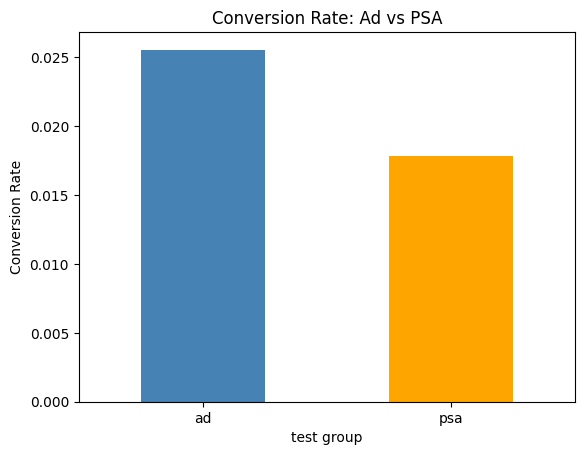

test group
ad     564577
psa     23524
Name: converted, dtype: int64


In [ ]:
# Conversion rate by group
conv_rate = df.groupby('test group')['converted'].mean()
print(conv_rate)

# Visualise
conv_rate.plot(kind='bar', color=['steelblue','orange'])
plt.title('Conversion Rate: Ad vs PSA')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

# Sample sizes
print(df.groupby('test group')['converted'].count())

In [ ]:
# NULL HYPOTHESIS (H0):
#   Conversion rate of Ad group == Conversion rate of PSA group
#   (ads had NO significant effect)

# ALTERNATIVE HYPOTHESIS (H1):
#   Conversion rate of Ad group > PSA group
#   (ads DID increase conversions)

# Significance level
alpha = 0.05
print(f"Alpha (significance level): {alpha}")

Alpha (significance level): 0.05


In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Baseline conversion rates
control = df[df['test group'] == 'psa']['converted']
treatment = df[df['test group'] == 'ad']['converted']

p1 = control.mean()
p2 = treatment.mean()

effect_size = proportion_effectsize(p1, p2)
power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=effect_size, alpha=alpha, power=0.8
)
print(f"Control conversion rate: {p1:.4f}")
print(f"Treatment conversion rate: {p2:.4f}")
print(f"Required sample size per group: {required_n:.0f}")
print(f"Actual sample sizes — Control: {len(control)}, Treatment: {len(treatment)}")

Control conversion rate: 0.0179
Treatment conversion rate: 0.0255
Required sample size per group: 5588
Actual sample sizes — Control: 23524, Treatment: 564577


In [ ]:
from scipy import stats

# Shapiro-Wilk test (on a sample since data is large)
sample_control = control.sample(500, random_state=42)
sample_treatment = treatment.sample(500, random_state=42)

stat_c, p_c = stats.shapiro(sample_control)
stat_t, p_t = stats.shapiro(sample_treatment)

print(f"Shapiro-Wilk — Control: stat={stat_c:.4f}, p={p_c:.4f}")
print(f"Shapiro-Wilk — Treatment: stat={stat_t:.4f}, p={p_t:.4f}")

# Since data is binary (0/1), not normally distributed
# --> We use Z-test for proportions (appropriate for binary conversion data)

Shapiro-Wilk — Control: stat=0.1198, p=0.0000
Shapiro-Wilk — Treatment: stat=0.1282, p=0.0000


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

successes = np.array([treatment.sum(), control.sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(successes, nobs, alternative='larger')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("RESULT: Reject H0 — ads significantly increased conversions")
else:
    print("RESULT: Fail to reject H0 — no significant difference found")

Z-statistic: 7.3701
P-value: 0.0000
RESULT: Reject H0 — ads significantly increased conversions


In [ ]:
from statsmodels.stats.proportion import proportion_confint

ci_control = proportion_confint(control.sum(), len(control), alpha=0.05)
ci_treatment = proportion_confint(treatment.sum(), len(treatment), alpha=0.05)

print(f"Control 95% CI: {ci_control[0]:.4f} – {ci_control[1]:.4f}")
print(f"Treatment 95% CI: {ci_treatment[0]:.4f} – {ci_treatment[1]:.4f}")

Control 95% CI: 0.0162 – 0.0195
Treatment 95% CI: 0.0251 – 0.0260
